In [1]:
# Практика 10. Неперервні розподіли в scipy.stats
# Коць Артем, ІТ-42
# Варіант 9 — Суми

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(9)

daily_temps = np.random.normal(
    loc=20,
    scale=2.5,
    size=30
)

print("Вибірка денних температур:")
print(daily_temps)

print("\nСереднє:", daily_temps.mean())
print("Стандартне відхилення:", daily_temps.std())

Вибірка денних температур:
[20.00277139 19.27613983 17.20983424 19.96779311 19.05409634 18.79716159
 16.20667205 18.77282005 19.39829855 18.38013135 21.5897277  24.35029326
 20.74170554 21.76875915 24.55703941 21.07692257 23.85682406 17.74819707
 19.65718747 23.24394753 21.68817792 20.07989529 22.29536474 20.95127367
 21.29091872 19.11190135 20.5219425  20.82102769 18.75443808 14.77055807]

Середнє: 20.198060677209607
Стандартне відхилення: 2.216077138642879


### Завдання 1. Побудова вибірки денних температур

Для варіанта 9 використано місто Суми. Середньомісячна температура
липня становить 20 °C.

За допомогою `np.random.normal()` згенеровано вибірку з 30 денних
температур із центром 20 °C та стандартним відхиленням 2.5 °C.

`np.random.seed(9)` забезпечує відтворюваність результату.
Середнє значення отриманої вибірки близьке до 20 °C, але не є
точно рівним цьому значенню, оскільки вибірка є випадковою.

In [2]:
mean = daily_temps.mean()
std = daily_temps.std()

dist = stats.norm(
    loc=mean,
    scale=std
)

print("μ =", mean)
print("σ =", std)
print("Нормальна модель:", dist)

μ = 20.198060677209607
σ = 2.216077138642879
Нормальна модель: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000264DCA09D30>


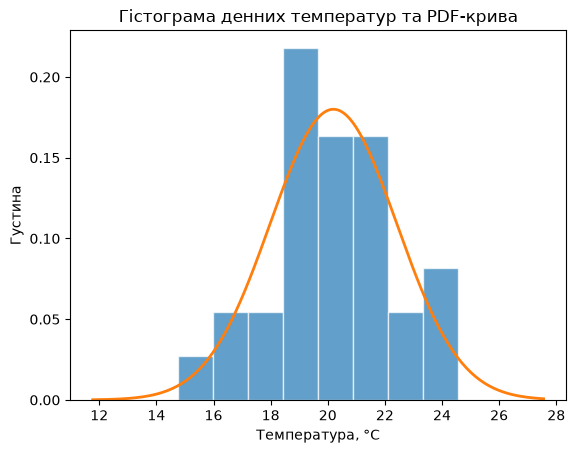

In [3]:
x = np.linspace(
    daily_temps.min() - 3,
    daily_temps.max() + 3,
    200
)

plt.hist(
    daily_temps,
    bins=8,
    density=True,
    edgecolor="white",
    alpha=0.7
)

plt.plot(
    x,
    dist.pdf(x),
    linewidth=2
)

plt.xlabel("Температура, °C")
plt.ylabel("Густина")
plt.title("Гістограма денних температур та PDF-крива")
plt.show()

### Завдання 3. Гістограма і теоретична pdf-крива

На гістограмі показано розподіл згенерованих денних температур.
Параметр `density=True` переводить гістограму в шкалу густини,
що дозволяє коректно порівнювати її з теоретичною PDF-кривою.

Крива побудована за допомогою `dist.pdf(x)` для нормального
розподілу, параметри якого отримані із середнього та стандартного
відхилення власної вибірки.

На графіку крива загалом проходить поблизу верхівок стовпців
гістограми. Невеликі відхилення є нормальними, оскільки вибірка
містить лише 30 випадкових значень.

In [4]:
lower = mean - std
upper = mean + std

probability = dist.cdf(upper) - dist.cdf(lower)

print("Нижня межа:", lower)
print("Верхня межа:", upper)
print("Ймовірність:", probability)
print("У відсотках:", probability * 100, "%")

Нижня межа: 17.98198353856673
Верхня межа: 22.414137815852484
Ймовірність: 0.6826894921370856
У відсотках: 68.26894921370857 %


### Завдання 4. Ймовірність потрапляння в діапазон

За допомогою `cdf()` обчислено ймовірність того, що денна
температура потрапить у межі одного стандартного відхилення
від середнього:

[mean - std, mean + std].

Для нормального розподілу правило 68-95-99.7 показує, що приблизно
68% значень повинні знаходитися в межах одного стандартного
відхилення від середнього.

Отримане значення відповідає теоретичному очікуванню для нормального
розподілу. Незначні відмінності можуть виникати через те, що
вибірка складається лише з 30 випадкових значень.

In [5]:
percentile_95 = dist.ppf(0.95)

print("95-й процентиль:", percentile_95)

95-й процентиль: 23.843183196310587


### Завдання 5. Квантиль через ppf()

За допомогою `dist.ppf(0.95)` знайдено температуру, яка відповідає
95-му процентилю підібраного нормального розподілу.

Отримане значення означає, що приблизно 95% значень теоретичного
нормального розподілу будуть нижчими за цю температуру, а приблизно
5% — вищими.

Функція `ppf()` є оберненою до `cdf()`. Функція `cdf()` отримує
значення температури та повертає накопичену ймовірність до цього
значення. Функція `ppf()` навпаки отримує задану накопичену
ймовірність і повертає відповідне їй значення температури.

## Письмові відповіді

### 1. У чому різниця між pdf(x) і cdf(x)?

`pdf(x)` повертає значення густини ймовірності в точці `x`.
Вона показує, наскільки щільно розподілені значення біля певної
точки. `pdf()` не є безпосередньо ймовірністю конкретного значення.

`cdf(x)` повертає накопичену ймовірність того, що випадкова величина
буде меншою або дорівнюватиме `x`. Тобто `CDF` відповідає на питання:
яка частка значень знаходиться зліва від заданого значення?

### 2. Чому pdf(x) може бути більшою за 1?

Значення `pdf(x)` може бути більшим за 1, оскільки PDF є густиною,
а не ймовірністю окремої точки.

Ймовірність визначається площею під кривою PDF на певному інтервалі.
Загальна площа під кривою дорівнює 1. Тому сама висота кривої може
бути більшою за 1 і це не є помилкою.

### 3. Чому ppf() називають оберненою до cdf()?

`cdf()` отримує значення випадкової величини та повертає накопичену
ймовірність. Наприклад, `cdf(x)` відповідає на питання, яка частина
розподілу знаходиться нижче `x`.

`ppf()` виконує зворотну операцію: отримує ймовірність і повертає
значення випадкової величини, якому ця ймовірність відповідає.

Наприклад, `ppf(0.95)` знаходить значення, нижче якого знаходиться
95% теоретичного розподілу.